# Liquidation Cascades: Detection & Follow-Through — with `candlefeed`

**The trader's question:** when a wave of forced liquidations rips through BTC perps, does price *keep going* in that direction (momentum you can ride) or does it *snap back* (a flush you can fade)? And how do you even define a "cascade" from raw data?

A liquidation is a forced trade: a long getting liquidated is a forced **sell**, a short getting liquidated is a forced **buy**. When enough leveraged positions sit at similar prices, one push triggers a chain — the textbook cascade. This notebook uses the official [CandleFeed](https://candlefeed.ai) client to:

1. Pull **tick-level liquidations** and bucket them into a per-minute USD intensity series.
2. **Detect cascade events** by clustering the extreme-intensity minutes.
3. Measure **price follow-through** at +15 / +30 / +60 minutes — momentum vs. mean-reversion — directionally, by whether the cascade was long- or short-dominated.
4. Use the **deep aggregated history** (back to 2024) for long-run context that tick data can't yet provide.

> **Data note (honest framing):** CandleFeed's **tick** liquidation feed is forward-captured and begins **2026-05-28**, so the cascade study below runs on ~11 days — enough to demonstrate the method and get a real (if small-sample) read, not enough to call it a strategy. The **aggregated** liquidation series reaches back to **2024**; we use it for the long-run backdrop.


In [1]:
# pip install candlefeed matplotlib pandas
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from candlefeed import CandleFeed

cf = CandleFeed()
print("Connected to CandleFeed:", cf.status()["status"])

Connected to CandleFeed: ok


## 1. The long-run backdrop (aggregated history, back to 2024)

Before zooming into ticks, anchor on scale. `get_liquidations_aggregated` returns CoinGlass-backfilled daily long/short liquidation USD — deep history the forward-captured tick feed doesn't have yet. This is the "how big do liquidation days get" reference.


daily rows: 889 | from 2024-01-01 to 2026-06-07

Biggest liquidation days on record:
                           long_liq_usd  short_liq_usd
timestamp                                             
2026-06-02 00:00:00+00:00          23.8          292.2
2025-10-10 00:00:00+00:00         176.2           46.0
2025-06-12 00:00:00+00:00         214.3            2.4
2026-06-05 00:00:00+00:00          65.9          138.8
2026-06-04 00:00:00+00:00          44.4          151.0


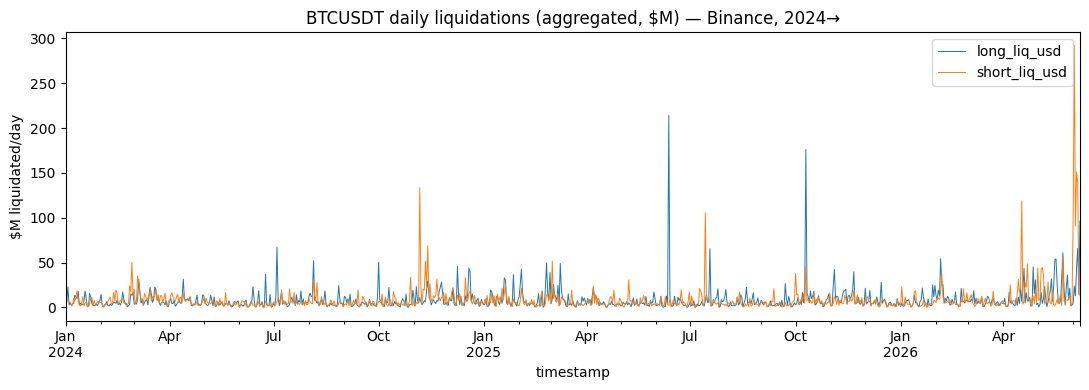

In [2]:
agg = cf.get_liquidations_aggregated(
    "BTCUSDT", exchange="binance", interval="1d",
    start="2024-01-01", end="2026-06-08", limit=2000,
)
agg = agg[agg.index.notna()]
agg["total"] = agg["long_liq_usd"] + agg["short_liq_usd"]
print("daily rows:", len(agg), "| from", agg.index.min().date(), "to", agg.index.max().date())

ax = (agg[["long_liq_usd", "short_liq_usd"]] / 1e6).plot(
    figsize=(11, 4), lw=0.7,
    title="BTCUSDT daily liquidations (aggregated, $M) — Binance, 2024→")
ax.set_ylabel("$M liquidated/day"); plt.tight_layout()

print("\nBiggest liquidation days on record:")
print((agg.sort_values("total", ascending=False)
        .head(5)[["long_liq_usd", "short_liq_usd"]] / 1e6).round(1).to_string())

## 2. Tick liquidations → per-minute intensity

Now the tick feed. Each row is a single forced trade with `side`, `quantity`, `price`, `usd_value`. We pull the live window and fetch matching 1-minute OHLCV so we can measure what price did around each event. We pivot ticks into a per-minute USD series split by side — `buy` = short liquidations (forced buying), `sell` = long liquidations (forced selling).


In [3]:
SYMBOL = "BTCUSDT"
START, END = "2026-05-28", "2026-06-08"   # tick-liquidation coverage window

tick = cf.get_liquidations(SYMBOL, exchange="binance", start=START, end=END).sort_index()
ohlcv = cf.get_ohlcv(SYMBOL, exchange="binance", interval="1m", start=START, end=END).sort_index()
print("tick liquidations:", tick.shape, "| 1m candles:", ohlcv.shape)

t = tick.copy()
t["minute"] = t.index.floor("1min")
per_min = (t.pivot_table(index="minute", columns="side", values="usd_value", aggfunc="sum")
             .reindex(ohlcv.index).fillna(0.0))
for col in ("buy", "sell"):
    if col not in per_min:
        per_min[col] = 0.0
per_min["total"] = per_min["buy"] + per_min["sell"]
per_min.head()

tick liquidations: (20239, 4) | 1m candles: (15831, 6)


side,buy,sell,total
time,,,
2026-05-28 00:01:00+00:00,0.0,0.0,0.0
2026-05-28 00:02:00+00:00,0.0,0.0,0.0
2026-05-28 00:03:00+00:00,0.0,0.0,0.0
2026-05-28 00:04:00+00:00,0.0,0.0,0.0
2026-05-28 00:05:00+00:00,0.0,0.0,0.0


## 3. Detect cascade events

A "cascade" is an unusually intense liquidation minute (here, the top 0.5% of non-zero minutes), with adjacent extreme minutes merged into a single event when they fall within 15 minutes of each other. For each event we record its size, peak 1-minute intensity, and **dominant side** (long- vs. short-liquidation).


In [4]:
liq_1m = per_min["total"]
thr = liq_1m[liq_1m > 0].quantile(0.995)
extreme = liq_1m[liq_1m >= thr].index.to_series()
event_id = (extreme.diff() > pd.Timedelta(minutes=15)).cumsum()

rows = []
for _, idx in extreme.groupby(event_id):
    t0, t1 = idx.min(), idx.max()
    win = per_min.loc[t0:t1]
    side = "short (forced buy)" if win["buy"].sum() >= win["sell"].sum() else "long (forced sell)"
    rows.append((t0, win["total"].sum(), win["total"].max(), side))

events = (pd.DataFrame(rows, columns=["start", "liq_usd", "peak_1m_usd", "side"])
            .sort_values("liq_usd", ascending=False).reset_index(drop=True))
print(f"Intensity threshold: ${thr:,.0f}/min | cascade events detected: {len(events)}")
ev_disp = events.copy()
ev_disp["liq_usd"] = (ev_disp["liq_usd"]/1e6).round(2)
ev_disp["peak_1m_usd"] = (ev_disp["peak_1m_usd"]/1e6).round(2)
ev_disp.rename(columns={"liq_usd":"liq_$M","peak_1m_usd":"peak_$M"}).head(12)

Intensity threshold: $7,337,827/min | cascade events detected: 18


,start,liq_$M,peak_$M,side
0,2026-06-07 22:13:00+00:00,71.68,31.99,short (forced buy)
1,2026-06-02 19:31:00+00:00,57.44,31.94,long (forced sell)
2,2026-06-02 02:06:00+00:00,48.24,30.77,long (forced sell)
3,2026-06-05 06:22:00+00:00,32.17,13.63,long (forced sell)
4,2026-06-04 02:02:00+00:00,29.20,17.47,long (forced sell)
5,2026-06-04 00:25:00+00:00,27.86,9.77,long (forced sell)
6,2026-06-02 14:01:00+00:00,22.61,10.88,long (forced sell)
7,2026-06-05 18:52:00+00:00,16.07,16.07,long (forced sell)
8,2026-06-05 06:03:00+00:00,12.94,12.94,long (forced sell)
9,2026-05-29 15:07:00+00:00,12.38,12.38,short (forced buy)


Let's see the single largest cascade in context — liquidation intensity against price. This is the anatomy of a flush.


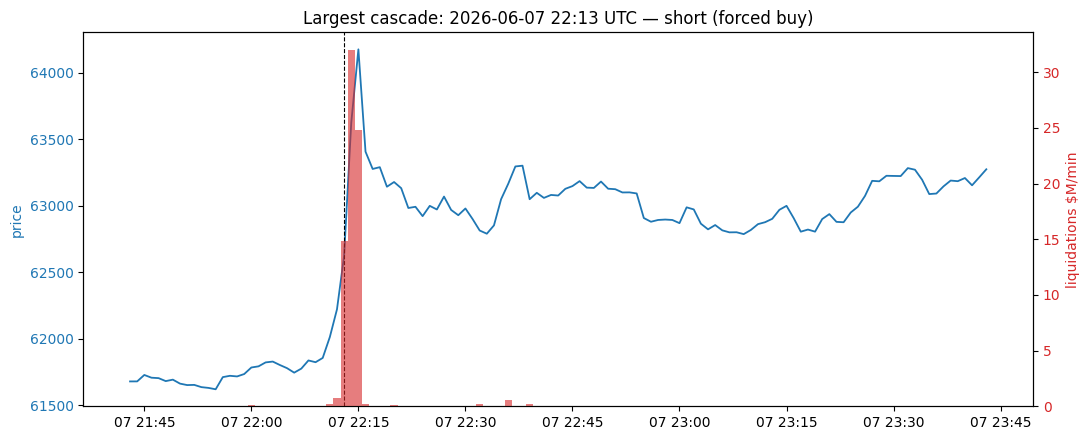

In [5]:
big = events.iloc[0]["start"]
w0, w1 = big - pd.Timedelta(minutes=30), big + pd.Timedelta(minutes=90)
px = ohlcv.loc[w0:w1, "close"]
li = per_min.loc[w0:w1, "total"] / 1e6

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(px.index, px.values, color="C0", lw=1.3, label="BTC close")
ax1.set_ylabel("price", color="C0"); ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
ax2.bar(li.index, li.values, width=0.0007, color="C3", alpha=0.6, label="liq $M/min")
ax2.set_ylabel("liquidations $M/min", color="C3"); ax2.tick_params(axis="y", labelcolor="C3")
ax1.axvline(big, color="k", ls="--", lw=0.8)
ax1.set_title(f"Largest cascade: {big:%Y-%m-%d %H:%M} UTC — {events.iloc[0]['side']}")
plt.tight_layout()

## 4. Follow-through: momentum or mean-reversion?

For each cascade we measure the forward return at +15 / +30 / +60 minutes, then express it as **continuation in the liquidation's direction**: a long-liquidation cascade is selling pressure, so price *continuing down* is positive continuation; a short-liquidation cascade is buying pressure, so price *continuing up* is positive continuation. Positive average ⇒ momentum (ride it). Negative ⇒ mean-reversion (fade it).


Mean CONTINUATION in the liquidation's direction (positive = momentum):
r15   -0.013
r30   -0.088
r60   -0.189

Events by dominant side: {'long (forced sell)': 16, 'short (forced buy)': 2}


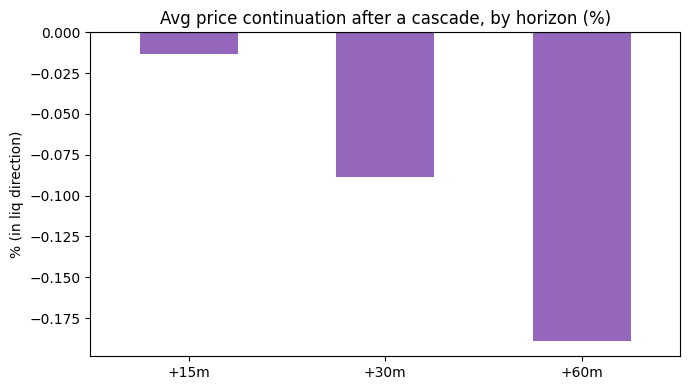

In [6]:
def fwd_ret(t, minutes):
    p0 = ohlcv["close"].asof(t)
    p1 = ohlcv["close"].asof(t + pd.Timedelta(minutes=minutes))
    return (p1 / p0 - 1) if (pd.notna(p0) and pd.notna(p1)) else np.nan

for h in (15, 30, 60):
    events[f"r{h}"] = events["start"].apply(lambda t: fwd_ret(t, h))

# +1 if cascade was short-driven (buy pressure, up = continuation), -1 if long-driven
events["dir"] = np.where(events["side"].str.startswith("short"), 1, -1)
cont = events[["r15", "r30", "r60"]].multiply(events["dir"], axis=0)

print("Mean CONTINUATION in the liquidation's direction (positive = momentum):")
print((cont.mean() * 100).round(3).to_string())
print("\nEvents by dominant side:", events["side"].value_counts().to_dict())

ax = (cont.mean() * 100).plot(kind="bar", figsize=(7, 4), color="C4",
        title="Avg price continuation after a cascade, by horizon (%)")
ax.axhline(0, color="k", lw=0.8); ax.set_ylabel("% (in liq direction)")
ax.set_xticklabels(["+15m", "+30m", "+60m"], rotation=0); plt.tight_layout()

## What the data actually says (and the honest caveats)

On this ~11-day window, the average post-cascade continuation is **slightly negative at every horizon** — i.e. a *mild* tendency for price to mean-revert after a liquidation flush rather than keep running. That's directionally consistent with the "forced sellers exhaust, weak hands flushed, price bounces" story traders tell about cascades.

**But be disciplined about the caveats — this is a template, not a signal you should trade tomorrow:**

- **Tiny sample.** ~A dozen cascade events over 11 days. The effect is small relative to the noise; a handful of events drive the average. Do not infer a Sharpe from this.
- **Forward-capture window only.** Tick liquidations start 2026-05-28. A real study needs months of events across regimes — the method here is what you'd re-run as the window grows.
- **Side classification is coarse.** "Dominant side" collapses a mixed event into one label; large cascades often liquidate both sides as price whipsaws (note the largest event was short-driven on a violent *up* move, not a down-flush).
- **Execution reality.** The forward returns are mid-to-mid on 1m closes — no fees, no slippage, no fill risk during the most volatile minutes of the day, which is exactly when these fire.

The value is the **reusable pipeline**: tick liquidations → intensity → event detection → forward-return study, on clean pandas frames. Point it at a longer window, more symbols, or pair it with `cf.get_open_interest(...)` and `cf.get_long_short_ratio(...)` to ask *where* the leverage was sitting before it blew up.

Docs and API keys: **[candlefeed.ai](https://candlefeed.ai)**.
